In [1]:
#part 1 - Build a co-occurance matrix
import numpy as np
from collections import defaultdict
import itertools
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import re

In [2]:
#define a large corpus
corpus = [
    "Natural language processing enables computers to understand human language.",
    "Machine learning is a part of artificial intelligence.",
    "Deep learning is a subfield of machine learning.",
    "Text data can be used for sentiment analysis.",
    "Named entity recognition is an information extraction technique.",
    "GloVe stands for Global Vectors for Word Representation.",
    "It captures semantic relationships between words.",
    "Word embeddings are useful for NLP applications.",
    "This tutorial implements GloVe from scratch.",
    "Sentiment analysis determines if a sentence is positive or negative."
]

In [5]:
#clean and tokenize 
def preprocess(sentence):
    return re.sub(r'[^a-zA-Z ]','',sentence).lower().split() # we are replacing anything that not alphabet to empty string

tokenized = [preprocess(sentence) for sentence in corpus]

In [6]:
tokenized

[['natural',
  'language',
  'processing',
  'enables',
  'computers',
  'to',
  'understand',
  'human',
  'language'],
 ['machine',
  'learning',
  'is',
  'a',
  'part',
  'of',
  'artificial',
  'intelligence'],
 ['deep', 'learning', 'is', 'a', 'subfield', 'of', 'machine', 'learning'],
 ['text', 'data', 'can', 'be', 'used', 'for', 'sentiment', 'analysis'],
 ['named',
  'entity',
  'recognition',
  'is',
  'an',
  'information',
  'extraction',
  'technique'],
 ['glove',
  'stands',
  'for',
  'global',
  'vectors',
  'for',
  'word',
  'representation'],
 ['it', 'captures', 'semantic', 'relationships', 'between', 'words'],
 ['word', 'embeddings', 'are', 'useful', 'for', 'nlp', 'applications'],
 ['this', 'tutorial', 'implements', 'glove', 'from', 'scratch'],
 ['sentiment',
  'analysis',
  'determines',
  'if',
  'a',
  'sentence',
  'is',
  'positive',
  'or',
  'negative']]

In [7]:
#build vocab
vocab = sorted(set(itertools.chain(*tokenized)))
vocab_size = len(vocab)

word2id = {word: i for i, word in enumerate(vocab)}
id2word = {i: word for word , i in word2id.items()}

In [8]:
vocab

['a',
 'an',
 'analysis',
 'applications',
 'are',
 'artificial',
 'be',
 'between',
 'can',
 'captures',
 'computers',
 'data',
 'deep',
 'determines',
 'embeddings',
 'enables',
 'entity',
 'extraction',
 'for',
 'from',
 'global',
 'glove',
 'human',
 'if',
 'implements',
 'information',
 'intelligence',
 'is',
 'it',
 'language',
 'learning',
 'machine',
 'named',
 'natural',
 'negative',
 'nlp',
 'of',
 'or',
 'part',
 'positive',
 'processing',
 'recognition',
 'relationships',
 'representation',
 'scratch',
 'semantic',
 'sentence',
 'sentiment',
 'stands',
 'subfield',
 'technique',
 'text',
 'this',
 'to',
 'tutorial',
 'understand',
 'used',
 'useful',
 'vectors',
 'word',
 'words']

In [9]:
word2id

{'a': 0,
 'an': 1,
 'analysis': 2,
 'applications': 3,
 'are': 4,
 'artificial': 5,
 'be': 6,
 'between': 7,
 'can': 8,
 'captures': 9,
 'computers': 10,
 'data': 11,
 'deep': 12,
 'determines': 13,
 'embeddings': 14,
 'enables': 15,
 'entity': 16,
 'extraction': 17,
 'for': 18,
 'from': 19,
 'global': 20,
 'glove': 21,
 'human': 22,
 'if': 23,
 'implements': 24,
 'information': 25,
 'intelligence': 26,
 'is': 27,
 'it': 28,
 'language': 29,
 'learning': 30,
 'machine': 31,
 'named': 32,
 'natural': 33,
 'negative': 34,
 'nlp': 35,
 'of': 36,
 'or': 37,
 'part': 38,
 'positive': 39,
 'processing': 40,
 'recognition': 41,
 'relationships': 42,
 'representation': 43,
 'scratch': 44,
 'semantic': 45,
 'sentence': 46,
 'sentiment': 47,
 'stands': 48,
 'subfield': 49,
 'technique': 50,
 'text': 51,
 'this': 52,
 'to': 53,
 'tutorial': 54,
 'understand': 55,
 'used': 56,
 'useful': 57,
 'vectors': 58,
 'word': 59,
 'words': 60}

In [10]:
id2word

{0: 'a',
 1: 'an',
 2: 'analysis',
 3: 'applications',
 4: 'are',
 5: 'artificial',
 6: 'be',
 7: 'between',
 8: 'can',
 9: 'captures',
 10: 'computers',
 11: 'data',
 12: 'deep',
 13: 'determines',
 14: 'embeddings',
 15: 'enables',
 16: 'entity',
 17: 'extraction',
 18: 'for',
 19: 'from',
 20: 'global',
 21: 'glove',
 22: 'human',
 23: 'if',
 24: 'implements',
 25: 'information',
 26: 'intelligence',
 27: 'is',
 28: 'it',
 29: 'language',
 30: 'learning',
 31: 'machine',
 32: 'named',
 33: 'natural',
 34: 'negative',
 35: 'nlp',
 36: 'of',
 37: 'or',
 38: 'part',
 39: 'positive',
 40: 'processing',
 41: 'recognition',
 42: 'relationships',
 43: 'representation',
 44: 'scratch',
 45: 'semantic',
 46: 'sentence',
 47: 'sentiment',
 48: 'stands',
 49: 'subfield',
 50: 'technique',
 51: 'text',
 52: 'this',
 53: 'to',
 54: 'tutorial',
 55: 'understand',
 56: 'used',
 57: 'useful',
 58: 'vectors',
 59: 'word',
 60: 'words'}

In [16]:
#build co-occurance matrix

def build_cooccurance_matrix(tokenized_corpus, vocab_size, word2id, window_size=2):
    cooccurance_matrix = np.zeros((vocab_size, vocab_size),dtype=np.float64)

    for sentence in tokenized_corpus:
        sentence_ids = [word2id[word] for word in sentence]
        for idx, word_id in enumerate(sentence_ids):
            start = max(idx - window_size, 0)
            end = min(idx + window_size +1, len(sentence_ids))

            for context_idx in range(start, end):
                if context_idx != idx:
                    context_id = sentence_ids[context_idx]
                    cooccurance_matrix[word_id, context_id] +=1
    return cooccurance_matrix

In [20]:
X = build_cooccurance_matrix(tokenized, vocab_size, word2id, window_size =2)

In [21]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(61, 61))

In [22]:
# Part 2: Initialize GloVe Parameters
np.random.seed(42)
embedding_dim = 50

W = np.random.randn(vocab_size, embedding_dim) / np.sqrt(embedding_dim)
W_tilde = np.random.randn(vocab_size, embedding_dim) / np.sqrt(embedding_dim)
biases_w = np.zeros(vocab_size)
biases_tilde = np.zeros(vocab_size)

non_zero_indices = np.nonzero(X)

# Weighting function
def weighting_func(x, x_max=100, alpha=0.75):
    f_x = np.where(x < x_max, (x / x_max) ** alpha, 1.0)
    return f_x

weights = weighting_func(X)

In [23]:
# Part 3: Train GloVe Embeddings
learning_rate = 0.05
num_epochs = 100

for epoch in range(num_epochs):
    total_loss = 0
    for i, j in zip(*non_zero_indices):
        x_ij = X[i, j]
        w_i = W[i]
        w_j = W_tilde[j]
        b_i = biases_w[i]
        b_j = biases_tilde[j]

        weight = weights[i, j]
        inner_product = np.dot(w_i, w_j)
        log_x_ij = np.log(x_ij)

        diff = (inner_product + b_i + b_j - log_x_ij)
        loss = weight * (diff ** 2)
        total_loss += loss

        grad_w_i = weight * diff * w_j
        grad_w_j = weight * diff * w_i
        grad_b_i = weight * diff
        grad_b_j = weight * diff

        W[i] -= learning_rate * grad_w_i
        W_tilde[j] -= learning_rate * grad_w_j
        biases_w[i] -= learning_rate * grad_b_i
        biases_tilde[j] -= learning_rate * grad_b_j

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

Epoch 10/100, Loss: 0.5122
Epoch 20/100, Loss: 0.4087
Epoch 30/100, Loss: 0.3379
Epoch 40/100, Loss: 0.2868
Epoch 50/100, Loss: 0.2482
Epoch 60/100, Loss: 0.2176
Epoch 70/100, Loss: 0.1927
Epoch 80/100, Loss: 0.1719
Epoch 90/100, Loss: 0.1542
Epoch 100/100, Loss: 0.1389


In [24]:
# Final embeddings
embeddings = W + W_tilde

In [25]:
# Part 4: Word Similarity (demo)
def most_similar(word, embeddings, word2id, id2word, top_n=5):
    idx = word2id[word]
    vec = embeddings[idx].reshape(1, -1)
    sims = cosine_similarity(vec, embeddings)[0]
    top_ids = sims.argsort()[::-1][1:top_n+1]
    return [(id2word[i], sims[i]) for i in top_ids]

print("\nSimilar words to 'learning':", most_similar("sentiment", embeddings, word2id, id2word))


Similar words to 'learning': [('embeddings', np.float64(0.40419005765359983)), ('implements', np.float64(0.3824689211280094)), ('analysis', np.float64(0.19952813786368812)), ('relationships', np.float64(0.17745634817343517)), ('artificial', np.float64(0.1604246222141652))]


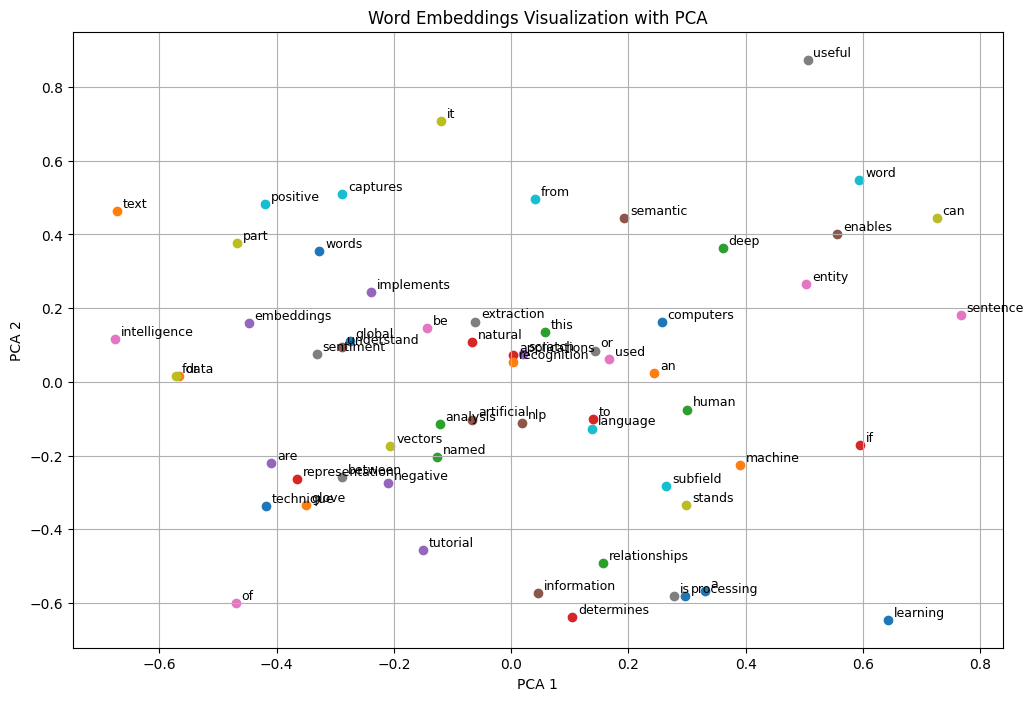

In [26]:
# Part 5: Visualize Embeddings
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
for i, word in id2word.items():
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=9)

plt.title("Word Embeddings Visualization with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [27]:
# Part 6: NLP Task - Sentiment Classification
# Define a toy dataset for sentiment analysis
sentences = [
    "I love natural language processing",
    "Deep learning is amazing",
    "This is a great tutorial",
    "I hate bugs in the code",
    "Debugging is so frustrating",
    "Errors make me angry"
]
labels = [1, 1, 1, 0, 0, 0]  # 1 = positive, 0 = negative

# Preprocess and average word vectors
X_data = []
for sent in sentences:
    words = preprocess(sent)
    vectors = [embeddings[word2id[word]] for word in words if word in word2id]
    if vectors:
        avg_vec = np.mean(vectors, axis=0)
    else:
        avg_vec = np.zeros(embedding_dim)
    X_data.append(avg_vec)

# Train a classifier
clf = LogisticRegression()
clf.fit(X_data, labels)

# Evaluate on training data
preds = clf.predict(X_data)
acc = accuracy_score(labels, preds)
print("\nSentiment Classification Accuracy:", acc)
for sent, label, pred in zip(sentences, labels, preds):
    print(f"{sent} => Actual: {label}, Predicted: {pred}")


Sentiment Classification Accuracy: 1.0
I love natural language processing => Actual: 1, Predicted: 1
Deep learning is amazing => Actual: 1, Predicted: 1
This is a great tutorial => Actual: 1, Predicted: 1
I hate bugs in the code => Actual: 0, Predicted: 0
Debugging is so frustrating => Actual: 0, Predicted: 0
Errors make me angry => Actual: 0, Predicted: 0
